# Designing a neural network

In [5]:
import torch.nn as nn
import torch

SEED=33
BATCH_SIZE=32

In [6]:
# example 1D input tensor
torch.manual_seed(SEED)
input_tensor = torch.randn(3, dtype=torch.float, device='mps')
input_tensor

tensor([-1.3376, -0.7121,  1.4028], device='mps:0')

In [7]:
# defining sample Linear layer
linear_layer = nn.Linear(
    in_features=3,
    out_features=2,
    bias=True,
    device='mps'
)
linear_layer


Linear(in_features=3, out_features=2, bias=True)

In [8]:
# Passing input through layer
output = linear_layer(input_tensor)
## inside thar function: input tensor @ weight tensor + biases => output
output

tensor([-0.6064,  1.0826], device='mps:0', grad_fn=<LinearBackward0>)

In [9]:
# weights and biases
print(linear_layer.weight)
print(linear_layer.bias)

Parameter containing:
tensor([[ 0.4029, -0.0242, -0.4543],
        [-0.3544, -0.0744,  0.2279]], device='mps:0', requires_grad=True)
Parameter containing:
tensor([0.5525, 0.2359], device='mps:0', requires_grad=True)


# Hidden layers & parameters

In [26]:
n_features = 32
n_classes = 3

In [27]:
# Stacking sample 3 layers with nn.Sequential
model = nn.Sequential(
    nn.Linear(n_features, 8),
    nn.Linear(8, 4),
    nn.Linear(4, n_classes),
    
)
torch.save(model, 'models/model_linear.pt')

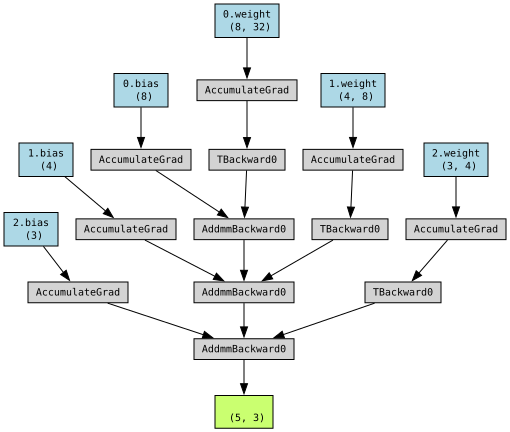

In [28]:
# import netron
# netron.start("models/model.pt")
from torchviz import make_dot
import torch

x = torch.randn(5, 32)
y = model(x)

make_dot(y, params=dict(model.named_parameters()))

In [31]:
total = 0
for parameter in model.parameters():
    total += parameter.numel()
print(total)

315


# Activation functions

In [34]:
### sigmoid
input_tensor = torch.tensor([[6]])
sigmoid = nn.Sigmoid()
output = sigmoid(input_tensor)
print(output)

tensor([[0.9975]])


tensor([[0.6787]], grad_fn=<SigmoidBackward0>)


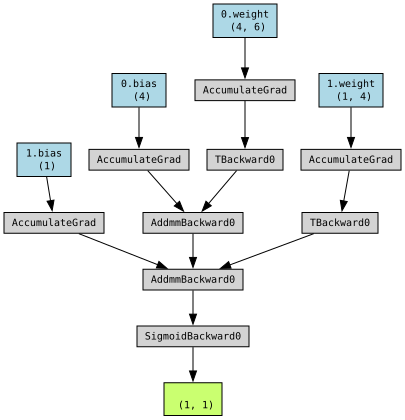

In [40]:
## last layer: sigmoid
model = nn.Sequential(
nn.Linear(6,4),
nn.Linear(4,1),
nn.Sigmoid(),
)
y = model(torch.randn(1,6))
print(y)
make_dot(y, params=dict(model.named_parameters()))

In [41]:
input_tensor = torch.tensor(
    [[4.3, 6.1, 2.3]]
)

probabs = nn.Softmax(dim=-1)
output_tensor = probabs(input_tensor)
output_tensor

tensor([[0.1392, 0.8420, 0.0188]])

In [49]:
model = nn.Sequential(
    nn.Linear(6,4),
    nn.Linear(4,3),
    nn.Softmax(dim=-1),
)
input_data = torch.randn((5,6))
output = model(input_data)
print(output.shape)

torch.Size([5, 3])


### One-hot encoding

In [52]:
import torch.nn.functional as F

print(F.one_hot(torch.tensor(0), num_classes = 3))
print(F.one_hot(torch.tensor(1), num_classes = 3))
print(F.one_hot(torch.tensor(2), num_classes = 3))

tensor([1, 0, 0])
tensor([0, 1, 0])
tensor([0, 0, 1])


### Cross-entropy loss in pytorch

In [59]:
from torch.nn import CrossEntropyLoss

scores = torch.tensor([-5.2, 4,6, 0.8])
target = torch.tensor(0)

criterion = CrossEntropyLoss()
print(criterion(scores.unsqueeze(0), one_hot_target.unsqueeze(0)))

tensor(11.3318)


### Backpropagation in PyTorch

In [66]:
model = nn.Sequential(
    nn.Linear(16, 8),
    nn.Linear(8, 4),
    nn.Linear(4, 2),
)

prediction = model(torch.randn(8, 16))
target = torch.randint(0, 2, (8,), dtype=torch.long)
criterion = CrossEntropyLoss()
loss = criterion(prediction, target)
loss.backward()

In [68]:
# Access each layer's gradients
model[0].weight.grad
model[0].bias.grad
model[1].weight.grad
model[1].bias.grad
model[2].weight.grad
model[2].bias.grad

tensor([ 0.3400, -0.3400])